<a href="https://colab.research.google.com/github/jaidvedant/AML/blob/main/AML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       -------------

/tmp/ipykernel_25135/2320529104.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_25135/2320529104.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

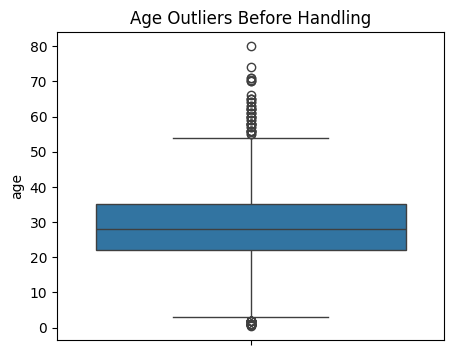


Dataset shape after removing outliers: (825, 14)


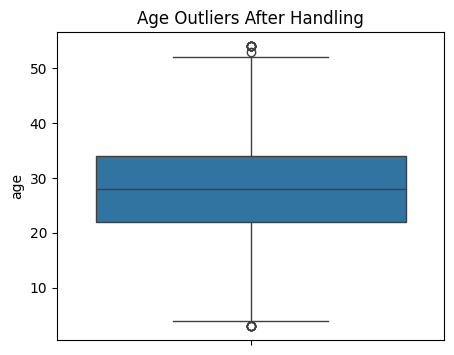


Dataset after Encoding:
   sex  embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2

Before Scaling:
    age     fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500

After Scaling:
        age      fare
0 -0.640556 -0.485389
1  0.932531  0.797171
2 -0.247284 -0.471869
3  0.637577  0.432967
4  0.637577 -0.469366

Final Preprocessed Dataset:
   survived  pclass  sex       age  sibsp  parch      fare  embarked  class  \
0         0       3    1 -0.640556      1      0 -0.485389         2  Third   
1         1       1    0  0.932531      1      0  0.797171         0  First   
2         1       3    0 -0.247284      0      0 -0.471869         2  Third   
3         1       1    0  0.637577      1      0  0.432967         2  First   
4         0       3    1  0.637577      0      0 -0.469366         2  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  w

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Using Titanic dataset from seaborn
df = sns.load_dataset('titanic')
print("First 5 rows of dataset:")
print(df.head())

# 1. Exploratory Data Analysis
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


# 2. Handle Missing Values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop(columns=['deck'], inplace=True)
print("\nMissing Values After Handling:")
print(df.isnull().sum())

# 3. Detect Outliers
plt.figure(figsize=(5,4))
sns.boxplot(df['age'])
plt.title("Age Outliers Before Handling")
plt.show()

# Remove outliers using IQR method
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['age'] >= lower) & (df['age'] <= upper)]
print("\nDataset shape after removing outliers:", df.shape)
plt.figure(figsize=(5,4))
sns.boxplot(df['age'])
plt.title("Age Outliers After Handling")
plt.show()

# 4. Encoding Categorical Data
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['embarked'] = label_encoder.fit_transform(df['embarked'])

print("\nDataset after Encoding:")
print(df[['sex', 'embarked']].head())

# 5. Feature Scaling
print("\nBefore Scaling:")
print(df[['age', 'fare']].head())

scaler = StandardScaler()

df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

print("\nAfter Scaling:")
print(df[['age', 'fare']].head())

# Final dataset
print("\nFinal Preprocessed Dataset:")
print(df.head())